# 1. Gaussian Naive Bayes

--- Gaussian Naive Bayes Model Evaluation on Iris Dataset ---

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


Confusion Matrix:


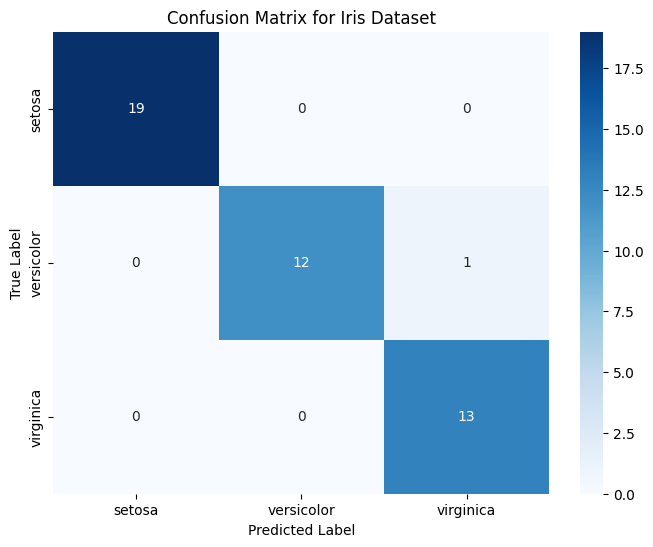


Example Probabilities (first 5 predictions):
[[4.15880005e-088 9.95527834e-001 4.47216606e-003]
 [1.00000000e+000 1.31031235e-013 2.21772205e-020]
 [9.83170191e-285 2.70138564e-012 1.00000000e+000]
 [9.54745274e-092 9.74861431e-001 2.51385686e-002]
 [1.08679560e-103 8.31910700e-001 1.68089300e-001]]


In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# 2. Split the data
# Using the same random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Create and Train the GaussianNB model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 4. Make Predictions
y_pred = gnb.predict(X_test)
probabilities = gnb.predict_proba(X_test)

# 5. Evaluate the model
print("--- Gaussian Naive Bayes Model Evaluation on Iris Dataset ---\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Iris Dataset')
plt.show()

print("\nExample Probabilities (first 5 predictions):")
print(probabilities[:5])


**Key Parameters:**
- `var_smoothing`: Portion of the largest variance added to all variances for stability (default: 1e-9)

---

# 2. Text Classification

Multinomial Naive Bayes Results
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Confusion Matrix:


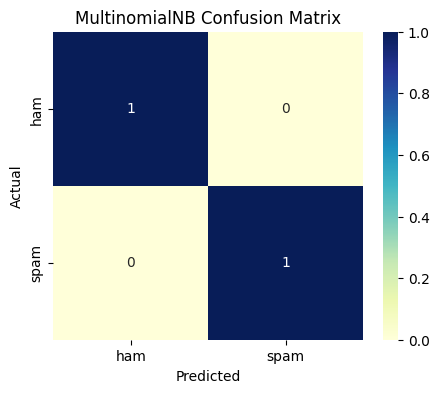

Example Probabilities (first 3 predictions):
Text: "Free money now click here"
Probabilities: ham=0.33, spam=0.67

Text: "Meeting scheduled for tomorrow"
Probabilities: ham=0.50, spam=0.50

Complement Naive Bayes Results


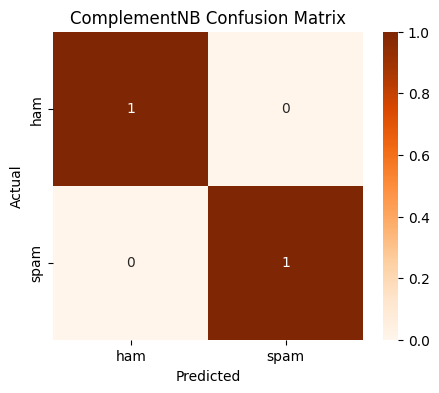

Confusion Matrix (ComplementNB):
[[1 0]
 [0 1]]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
texts = [
    "Free money now click here",
    "Meeting scheduled for tomorrow",
    "Win a free iPhone today",
    "Project deadline next week",
    "Claim your prize immediately",
    "Team lunch on Friday"
]
labels = ['spam', 'ham', 'spam', 'ham', 'spam', 'ham']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.33, random_state=42
)

# Method 1: Count Vectorizer
count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

# Method 2: TF-IDF Vectorizer (often better)
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Train Multinomial Naive Bayes
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train_counts, y_train)

# Predict
y_pred = mnb.predict(X_test_counts)
y_proba = mnb.predict_proba(X_test_counts)

# Evaluate
print("="*40)
print("Multinomial Naive Bayes Results")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MultinomialNB Confusion Matrix')
plt.show()

print("Example Probabilities (first 3 predictions):")
for i, (text, probs) in enumerate(zip(X_test, y_proba)):
    print(f"Text: \"{text}\"")
    print(f"Probabilities: ham={probs[0]:.2f}, spam={probs[1]:.2f}\n")
    if i == 2:
        break

# For imbalanced data, try Complement NB
print("="*40)
print("Complement Naive Bayes Results")
print("="*40)
cnb = ComplementNB(alpha=1.0)
cnb.fit(X_train_counts, y_train)
y_pred_complement = cnb.predict(X_test_counts)
cm_complement = confusion_matrix(y_test, y_pred_complement, labels=['ham', 'spam'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_complement, annot=True, fmt='d', cmap='Oranges', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ComplementNB Confusion Matrix')
plt.show()
print("Confusion Matrix (ComplementNB):")
print(cm_complement)